c:\Users\ahmad\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Config Loaded (XGBoost Full Reporting Edition).
[INFO] 16:45:55 - Scanning Data...
   + Loaded: final_moving_avg_devID109_test_prepared.csv [TRAIN]
   + Loaded: label_for_dev108_test_prepared.csv [TRAIN]
   + Loaded: label_for_dev109_test_prepared.csv [TRAIN]
   + Loaded: monitoring_data_2025-11-22_19-57-13_prepared.csv [TEST]
   + Loaded: moving_avg_for_train_prepared.csv [TRAIN]
[INFO] 16:45:55 - Feature Engineering (Physics + AI Models)...
   -> Loaded Isolation Forest Model
   -> Loaded LSTM Autoencoder Model
[INFO] 16:45:56 - Scaling Data...

🚀 HORIZON: +0.0 Hours (0 mins)
⚖️ Balancing Train Data...
   Original counts: Counter({np.int64(0): 27798, np.int64(1): 776, np.int64(2): 528})
🔍 Running Bayesian Optimization (20 trials)...
   🏆 Best Params: {'n_estimators': 392, 'learning_rate': 0.020699870876966394, 'max_depth': 6, 'subsample': 0.7971026844837515, 'colsample_bytree': 0.6103840502664116, 'min_child_weight': 5, 'gamma': 2.1933051326799005}
   Training Final Model...

=====

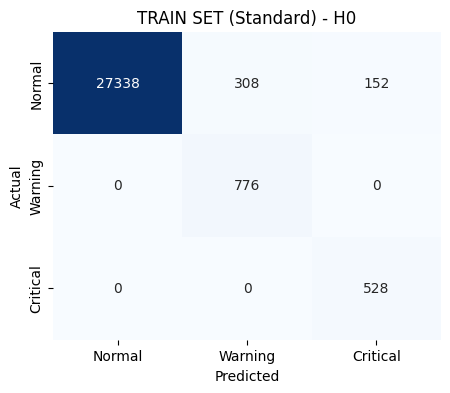

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     27798
     Warning       0.72      1.00      0.83       776
    Critical       0.78      1.00      0.87       528

    accuracy                           0.98     29102
   macro avg       0.83      0.99      0.90     29102
weighted avg       0.99      0.98      0.99     29102



==================== VAL SET (Standard) - H0 ====================


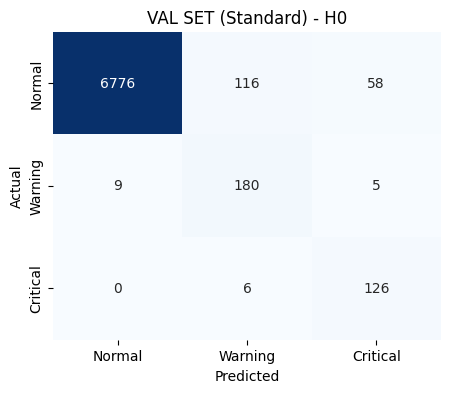

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99      6950
     Warning       0.60      0.93      0.73       194
    Critical       0.67      0.95      0.79       132

    accuracy                           0.97      7276
   macro avg       0.75      0.95      0.83      7276
weighted avg       0.98      0.97      0.98      7276



==================== TEST SET (Standard) - H0 ====================


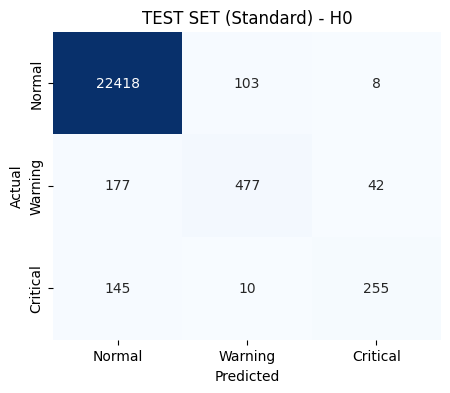

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     22529
     Warning       0.81      0.69      0.74       696
    Critical       0.84      0.62      0.71       410

    accuracy                           0.98     23635
   macro avg       0.88      0.77      0.82     23635
weighted avg       0.98      0.98      0.98     23635


[INFO] 17:15:53 - 🔧 Tuning Safety Thresholds...
   🔥 Best Thresholds -> Crit: 0.30, Warn: 0.25
[INFO] 17:15:54 - Evaluating Test Set (Tuned)...

==================== TEST SET (Tuned: C>0.30, W>0.25) ====================


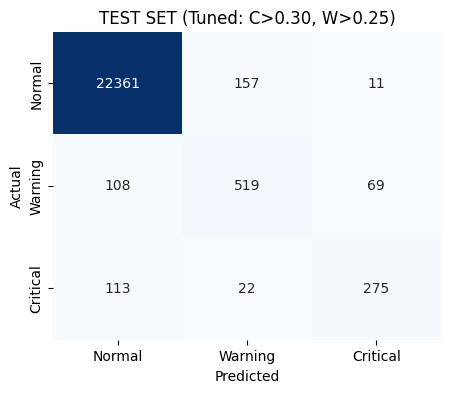

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     22529
     Warning       0.74      0.75      0.74       696
    Critical       0.77      0.67      0.72       410

    accuracy                           0.98     23635
   macro avg       0.84      0.80      0.82     23635
weighted avg       0.98      0.98      0.98     23635



=== FINAL SUMMARY (BAYESIAN) ===
   Horizon       Acc   F1_Norm  F1_Warn   F1_Crit
0        0  0.979691  0.991377  0.74462  0.718954


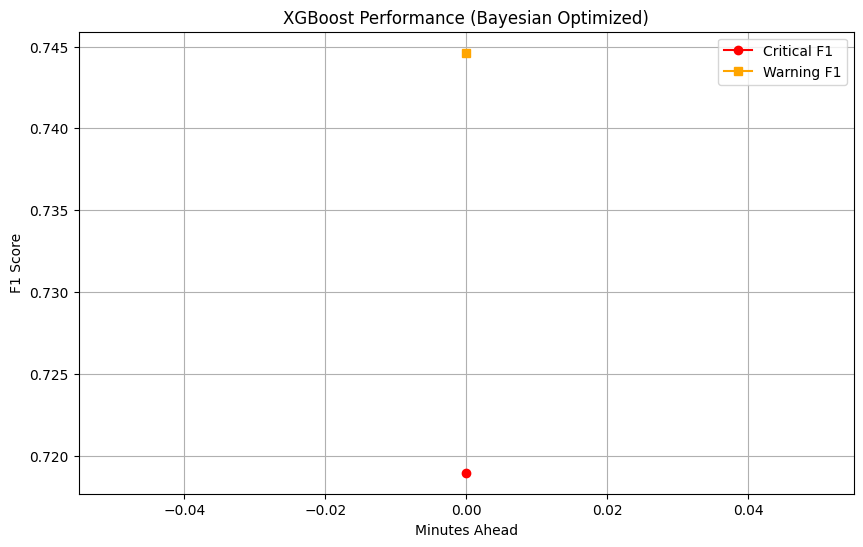

In [1]:
# %%
# ====================================================================
# 1. IMPORTS & CONFIGURATION
# ====================================================================
import os
import glob
import time
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Advanced Models Support
import optuna 
import xgboost as xgb
from tensorflow.keras.models import load_model 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, recall_score

import warnings
warnings.filterwarnings('ignore')

# ตั้งค่าให้แสดงผลกราฟใน Jupyter
%matplotlib inline 

class Config:
    # --- PATHS ---
    DATA_DIR = "./data/"
    MODEL_DIR = "./model/xgboost_bayes/"
    SCALER_PATH = "./model/xgboost_bayes_scaler.save"
    
    # Path สำหรับ Model ช่วย (Feature Engineering)
    # ** ตรวจสอบ Path ให้ถูกต้อง **
    ISO_MODEL_PATH = './../models/IsolationForest/model/iso_model2.joblib'
    ISO_SCALER_PATH = './../models/IsolationForest/model/iso_scaler2.joblib'
    LSTM_MODEL_PATH = './../models/LSTM_Autoencoders/lstm_autoencoder_model_fit.h5'
    LSTM_SCALER_PATH = './../models/LSTM_Autoencoders/scaler_fit.save'
    
    # --- SETTINGS ---
    HORIZONS = [0] # นาทีล่วงหน้า (ปรับเพิ่มได้ เช่น [0, 30, 60])
    SEQUENCE_LENGTH = 60
    TEST_KEYWORDS = ['monitoring_data_2025-11-22_19-57-13_prepared']
    
    RAW_COLS = ['rain', 'soil', 'temp', 'humi', 'geo']
    LABEL_COL = 'label'
    LABEL_MAP = {'normal': 0, 'warning': 1, 'critical': 2}
    
    # --- Data Strategy ---
    TARGET_SAMPLES = 10000     
    CLASS_WEIGHTS = {0: 1.0, 1: 2.0, 2: 3.0} 
    
    # --- Bayesian Optimization Settings ---
    OPTUNA_TRIALS = 20
    
    # Fixed XGB params
    XGB_FIXED = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'n_jobs': -1,
        'random_state': 42,
        'tree_method': 'hist', # เร็วและแม่นยำ
        'early_stopping_rounds': 15
    }

cfg = Config()
if not os.path.exists(cfg.MODEL_DIR): os.makedirs(cfg.MODEL_DIR)
np.random.seed(42); random.seed(42)

def log(msg): print(f"[INFO] {time.strftime('%H:%M:%S')} - {msg}")
print("✅ Config Loaded (XGBoost Full Reporting Edition).")

# %%
# ====================================================================
# 2. DATA LOADING & ADVANCED FEATURE ENGINEERING
# ====================================================================
def load_data():
    log("Scanning Data...")
    files = glob.glob(os.path.join(cfg.DATA_DIR, "*.csv"))
    if not files: files = glob.glob(os.path.join(cfg.DATA_DIR, "**/*.csv"), recursive=True)
    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df.columns = [str(c).lower().strip().replace('.1', '') for c in df.columns]
            rename_map = {'temperature':'temp', 'hum':'humi', 'humidity':'humi', 'devid':'devID', 'time':'timestamp', 'date':'timestamp'}
            new_cols = {c: rename_map[c] for c in df.columns if c in rename_map}
            if new_cols: df = df.rename(columns=new_cols)
            if 'devID' in df.columns: df['devID'] = df['devID'].astype(str).str.extract('(\d+)')[0].astype(float).fillna(0).astype(int)
            if 'timestamp' in df.columns: df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
            for c in cfg.RAW_COLS: 
                if c not in df.columns: df[c] = 0.0
            filename = os.path.basename(f)
            df['is_test'] = any(k in filename for k in cfg.TEST_KEYWORDS)
            dfs.append(df)
            print(f"   + Loaded: {filename} [{'TEST' if df['is_test'].iloc[0] else 'TRAIN'}]")
        except: pass
    return pd.concat(dfs, ignore_index=True) if dfs else None

def generate_features(df):
    log("Feature Engineering (Physics + AI Models)...")
    df = df.sort_values(['devID', 'timestamp']).reset_index(drop=True)
    df_list = []
    
    # Load Helper Models
    iso_model, iso_scaler = None, None
    lstm_model, lstm_scaler = None, None

    try:
        iso_model = joblib.load(cfg.ISO_MODEL_PATH)
        iso_scaler = joblib.load(cfg.ISO_SCALER_PATH)
        print("   -> Loaded Isolation Forest Model")
    except Exception as e: print(f"   [WARN] Could not load ISO Model: {e}")

    try:
        # ใส่ compile=False เพื่อแก้ปัญหา 'mse' error
        lstm_model = load_model(cfg.LSTM_MODEL_PATH, compile=False)
        lstm_scaler = joblib.load(cfg.LSTM_SCALER_PATH)
        print("   -> Loaded LSTM Autoencoder Model")
    except Exception as e: 
        print(f"   [WARN] Could not load LSTM Model: {e}")

    # Processing Loop
    for dev, g in df.groupby('devID'):
        g = g.set_index('timestamp')
        g = g[~g.index.duplicated(keep='first')]
        if len(g) > 0: g = g.resample('1T').asfreq()
        g[cfg.RAW_COLS] = g[cfg.RAW_COLS].interpolate(limit_direction='both').fillna(0)
        
        # Physics
        g['rain_1h'] = g['rain'].rolling(60, min_periods=1).sum()
        g['soil_rate'] = g['soil'].diff().fillna(0)
        g['soil_acc']  = g['soil'].diff().diff().fillna(0)
        g['rain_6h'] = g['rain'].rolling(360, min_periods=1).sum()
        g['soil_trend_6h'] = g['soil'] - g['soil'].shift(360).fillna(method='bfill')
        g['rain_24h'] = g['rain'].rolling(1440, min_periods=1).sum()
        g['soil_max_24h'] = g['soil'].rolling(1440, min_periods=1).max()
        g['rain_x_soil'] = g['rain'] * g['soil']
        
        # AI Features
        if iso_model and iso_scaler:
            try:
                X_iso = iso_scaler.transform(g[cfg.RAW_COLS].values)
                g['feat_iso_score'] = iso_model.decision_function(X_iso)
            except: g['feat_iso_score'] = 0.0
        else: g['feat_iso_score'] = 0.0
            
        if lstm_model and lstm_scaler:
            try:
                data_values = g[cfg.RAW_COLS].values
                X_lstm = lstm_scaler.transform(data_values)
                if X_lstm.ndim == 2: X_reshaped = X_lstm.reshape(X_lstm.shape[0], 1, X_lstm.shape[1]) 
                else: X_reshaped = X_lstm
                preds = lstm_model.predict(X_reshaped, verbose=0)
                mae = np.mean(np.abs(X_reshaped - preds), axis=2).flatten()
                g['feat_lstm_error'] = mae
            except: g['feat_lstm_error'] = 0.0
        else: g['feat_lstm_error'] = 0.0

        if cfg.LABEL_COL in g.columns:
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].fillna('normal').astype(str).str.lower().str.strip()
            g[cfg.LABEL_COL] = g[cfg.LABEL_COL].map(cfg.LABEL_MAP).fillna(0).astype(int)
        else: g[cfg.LABEL_COL] = 0
        g['is_test'] = g['is_test'].fillna(method='ffill').fillna(method='bfill')
        g['devID'] = dev
        df_list.append(g.reset_index())
        
    return pd.concat(df_list, ignore_index=True).fillna(0)

df_train_raw = load_data()
df_proc = generate_features(df_train_raw)

# %%
# ====================================================================
# 3. PREPARATION
# ====================================================================
def create_sequences_vectorized(df, feature_cols, horizon):
    Xs, ys, is_tests = [], [], []
    for dev, g in df.groupby('devID'):
        data = g[feature_cols].values
        labels = g[cfg.LABEL_COL].shift(-horizon).values
        test_flag = g['is_test'].values
        valid_len = len(g) - horizon
        if valid_len < cfg.SEQUENCE_LENGTH: continue
        windows = np.lib.stride_tricks.sliding_window_view(data[:valid_len], window_shape=(cfg.SEQUENCE_LENGTH, len(feature_cols))).squeeze()
        windows_flat = windows.reshape(windows.shape[0], -1)
        target_labels = labels[cfg.SEQUENCE_LENGTH-1 : valid_len]
        target_tests = test_flag[cfg.SEQUENCE_LENGTH-1 : valid_len]
        min_len = min(len(windows_flat), len(target_labels))
        Xs.append(windows_flat[:min_len]); ys.append(target_labels[:min_len]); is_tests.append(target_tests[:min_len])
    if not Xs: return np.array([]), np.array([]), np.array([])
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(is_tests)

def balance_data(X, y):
    print(f"   Original counts: {Counter(y)}")
    X_bal, y_bal = [], []
    for cls in np.unique(y):
        if np.isnan(cls): continue
        indices = np.where(y == cls)[0]
        count = len(indices); target = cfg.TARGET_SAMPLES; replace = count < target
        n_samples = target if replace else count 
        chosen_indices = np.random.choice(indices, n_samples, replace=replace)
        X_bal.append(X[chosen_indices]); y_bal.append(y[chosen_indices])
    X_bal = np.concatenate(X_bal); y_bal = np.concatenate(y_bal)
    perm = np.random.permutation(len(X_bal))
    return X_bal[perm], y_bal[perm]

# ====================================================================
# 4. VISUALIZATION & REPORTING HELPER
# ====================================================================
def evaluate_and_print(y_true, y_pred, title):
    """
    1. Plots Confusion Matrix (Heatmap)
    2. Prints Classification Report (Precision, Recall, F1 for EACH class)
    """
    print(f"\n{'='*20} {title} {'='*20}")
    
    # 1. Plot Heatmap
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    class_names = ['Normal', 'Warning', 'Critical']
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()
    
    # 2. Print Text Report
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print(f"{'='*50}\n")

# ====================================================================
# 5. BAYESIAN & THRESHOLD OPTIMIZATION (XGBoost)
# ====================================================================
def objective(trial, X_train, y_train, X_val, y_val, sample_weights):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
    }
    full_params = {**cfg.XGB_FIXED, **params}
    
    model = xgb.XGBClassifier(**full_params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = model.predict(X_val)
    rec_c = recall_score(y_val, preds, labels=[2], average=None)[0] if 2 in y_val else 0
    f1_c  = f1_score(y_val, preds, labels=[2], average=None)[0] if 2 in y_val else 0
    safety_score = (rec_c * 2.0) + f1_c
    return safety_score

def optimize_thresholds_for_safety(model, X_val, y_val_true):
    log("🔧 Tuning Safety Thresholds...")
    probs = model.predict_proba(X_val) 
    best_score = -1; best_thresh_crit = 0.5; best_thresh_warn = 0.5
    
    for t_crit in np.arange(0.1, 0.9, 0.05):
        for t_warn in np.arange(0.1, 0.9, 0.05):
            if t_warn >= t_crit: continue 
            preds = np.zeros(len(probs), dtype=int)
            crit_mask = probs[:, 2] >= t_crit; preds[crit_mask] = 2
            warn_mask = (~crit_mask) & (probs[:, 1] >= t_warn); preds[warn_mask] = 1
            
            rec_c = recall_score(y_val_true, preds, labels=[2], average=None, zero_division=0)[0] if 2 in np.unique(y_val_true) else 0
            f1_c = f1_score(y_val_true, preds, labels=[2], average=None, zero_division=0)[0] if 2 in np.unique(y_val_true) else 0
            f1_w = f1_score(y_val_true, preds, labels=[1], average=None, zero_division=0)[0] if 1 in np.unique(y_val_true) else 0
            score = (rec_c * 2.0) + f1_c + (f1_w * 0.5)
            
            if score > best_score:
                best_score = score; best_thresh_crit = t_crit; best_thresh_warn = t_warn
                
    print(f"   🔥 Best Thresholds -> Crit: {best_thresh_crit:.2f}, Warn: {best_thresh_warn:.2f}")
    return best_thresh_crit, best_thresh_warn

def predict_with_tuned_thresholds(model, X, t_crit, t_warn):
    probs = model.predict_proba(X)
    preds = np.zeros(len(probs), dtype=int)
    crit_mask = probs[:, 2] >= t_crit; preds[crit_mask] = 2
    warn_mask = (~crit_mask) & (probs[:, 1] >= t_warn); preds[warn_mask] = 1
    return preds

# ====================================================================
# 6. MAIN LOOP
# ====================================================================
def train_system():
    FINAL_FEATURES = cfg.RAW_COLS + [
        'rain_1h', 'soil_rate', 'soil_acc', 'rain_6h', 'soil_trend_6h', 
        'rain_24h', 'soil_max_24h', 'rain_x_soil', 
        'feat_iso_score', 'feat_lstm_error'
    ]
    
    log("Scaling Data...")
    scaler = StandardScaler()
    train_mask = ~df_proc['is_test']
    scaler.fit(df_proc.loc[train_mask, FINAL_FEATURES])
    df_proc[FINAL_FEATURES] = scaler.transform(df_proc[FINAL_FEATURES])
    joblib.dump(scaler, cfg.SCALER_PATH)
    
    results_log = []

    for h in cfg.HORIZONS:
        print(f"\n{'='*60}")
        print(f"🚀 HORIZON: +{h/60:.1f} Hours ({h} mins)")
        print(f"{'='*60}")
        
        # Prepare & Split
        X_all, y_all, test_mask = create_sequences_vectorized(df_proc, FINAL_FEATURES, h)
        if len(X_all) == 0: continue
        X_train = X_all[~test_mask]; y_train = y_all[~test_mask]
        X_test  = X_all[test_mask];  y_test  = y_all[test_mask]
        valid_tr = ~np.isnan(y_train); X_train = X_train[valid_tr]; y_train = y_train[valid_tr]
        valid_ts = ~np.isnan(y_test);  X_test = X_test[valid_ts];   y_test = y_test[valid_ts]
        X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
        
        # Balance & Optimize
        print("⚖️ Balancing Train Data...")
        X_train_bal, y_train_bal = balance_data(X_train, y_train)
        safety_factor = 1.0 + (h/1440.0)
        sample_weights = np.array([cfg.CLASS_WEIGHTS[y] * safety_factor for y in y_train_bal])
        
        print(f"🔍 Running Bayesian Optimization ({cfg.OPTUNA_TRIALS} trials)...")
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(lambda trial: objective(trial, X_train_bal, y_train_bal, X_val, y_val, sample_weights), n_trials=cfg.OPTUNA_TRIALS)
        
        best_params = study.best_params
        print(f"   🏆 Best Params: {best_params}")
        
        # Train Final
        print("   Training Final Model...")
        final_params = {**cfg.XGB_FIXED, **best_params}
        model = xgb.XGBClassifier(**final_params)
        model.fit(
            X_train_bal, y_train_bal,
            sample_weight=sample_weights,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        save_path = os.path.join(cfg.MODEL_DIR, f"xgboost_bayes_h{h}.json")
        model.save_model(save_path)
        
        # ==========================================================
        # 📊 FULL EVALUATION (GRAPH + TABLE)
        # ==========================================================
        
        # 4.1 TRAIN SET
        y_train_pred = model.predict(X_train)
        evaluate_and_print(y_train, y_train_pred, f"TRAIN SET (Standard) - H{h}")

        # 4.2 VALIDATION SET
        y_val_pred = model.predict(X_val)
        evaluate_and_print(y_val, y_val_pred, f"VAL SET (Standard) - H{h}")
        
        # 4.3 TEST SET (Standard)
        y_test_pred_std = model.predict(X_test)
        evaluate_and_print(y_test, y_test_pred_std, f"TEST SET (Standard) - H{h}")

        # ==========================================================
        # 5. TUNED EVALUATION
        # ==========================================================
        t_crit, t_warn = optimize_thresholds_for_safety(model, X_val, y_val)
        with open(os.path.join(cfg.MODEL_DIR, f"thresh_h{h}.txt"), "w") as f: f.write(f"{t_crit},{t_warn}")
        
        log(f"Evaluating Test Set (Tuned)...")
        y_pred_tuned = predict_with_tuned_thresholds(model, X_test, t_crit, t_warn)
        
        evaluate_and_print(y_test, y_pred_tuned, f"TEST SET (Tuned: C>{t_crit:.2f}, W>{t_warn:.2f})")
        
        # Logging
        acc = accuracy_score(y_test, y_pred_tuned)
        report = classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Warning', 'Critical'], output_dict=True, zero_division=0)
        def get_rep(label): return report.get(label, {'f1-score':0})['f1-score']
        results_log.append({'Horizon': h, 'Acc': acc, 'F1_Norm': get_rep('Normal'), 'F1_Warn': get_rep('Warning'), 'F1_Crit': get_rep('Critical')})

    summary = pd.DataFrame(results_log)
    summary.to_csv("./model/xgboost_bayes_performance.csv", index=False)
    print("\n=== FINAL SUMMARY (BAYESIAN) ===")
    print(summary)
    
    plt.figure(figsize=(10, 6))
    plt.plot(summary['Horizon'], summary['F1_Crit'], marker='o', color='red', label='Critical F1')
    plt.plot(summary['Horizon'], summary['F1_Warn'], marker='s', color='orange', label='Warning F1')
    plt.title("XGBoost Performance (Bayesian Optimized)")
    plt.xlabel("Minutes Ahead")
    plt.ylabel("F1 Score")
    plt.legend(); plt.grid(True)
    plt.show()

if __name__ == "__main__":
    train_system()